# `AA Workshop 13` — Coding Challenge

Complete the tasks below to practice time series techniques from `W13_Time_Series.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- checking if a time series is stationary
- determining p, d and q of an ARIMA model
- training and evaluating an ARIMA model
- generating time series predictions

## Task 1 - Predicting U.S. Real GDP

Let's put what we have learned about time-series forecasting into practice. For this task, we aim to predict U.S. Real GDP. You can load the data as follows:

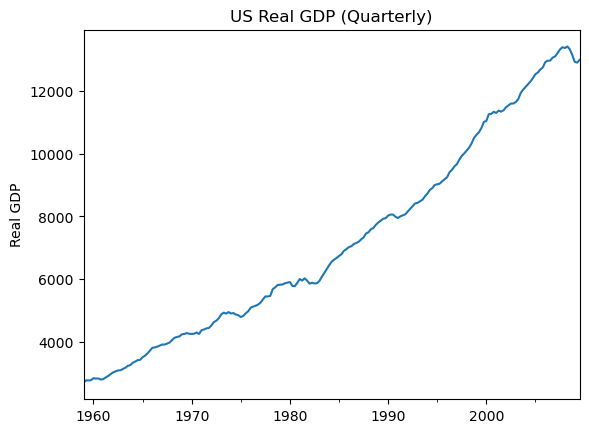

In [1]:
from statsmodels.datasets import macrodata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load macroeconomic dataset
data = macrodata.load_pandas().data

# create a quarterly datetime index
dates = pd.period_range(
    start=f"{int(data.year.iloc[0])}Q{int(data.quarter.iloc[0])}",
    periods=len(data),
    freq="Q"
)
data.index = dates.to_timestamp()

ts = data["realgdp"]

ts.plot(title="US Real GDP (Quarterly)")
plt.ylabel("Real GDP")
plt.show()

Complete the following steps:
- **Determine d**: ARIMA models require stationary time series. Check whether the time-series is stationary using the Augmented Dickey-Fuller test. If not, apply differencing and check again.
- **Determine p & q**: Generate ACF and PACF plots of the stationary series to determine possible values for p & q.
- **Train & evaluate ARIMA models**: train and evaluate ARIMA models with potentially suitable values for p, d & q. Remember to perform a train/test split (note that our usual approach of randomly splitting data points into train and test sets does not work with time-series data. Instead, you might want to check out https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).
- **Generate predictions**: Plot true and predicted values generated by your best performing model.

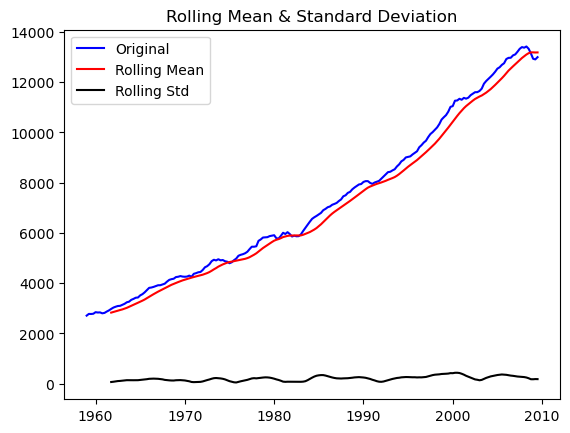

Results of Dickey-Fuller Test: p-value 0.9982455372335032





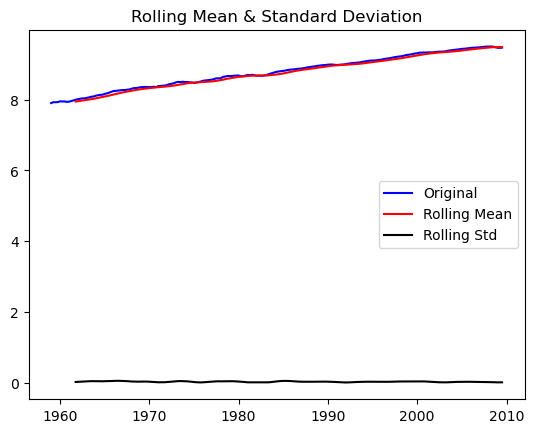

Results of Dickey-Fuller Test: p-value 0.3827723399149292





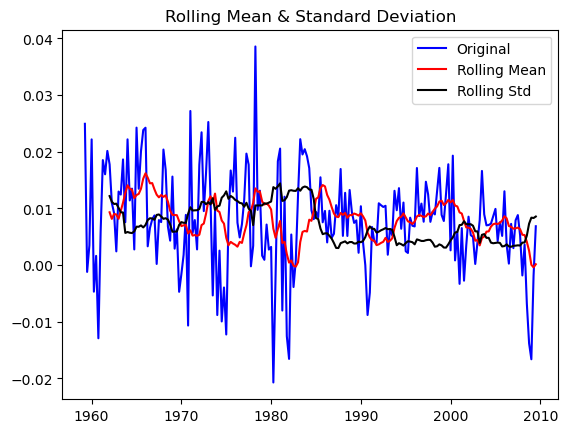

Results of Dickey-Fuller Test: p-value 8.575095844895221e-10





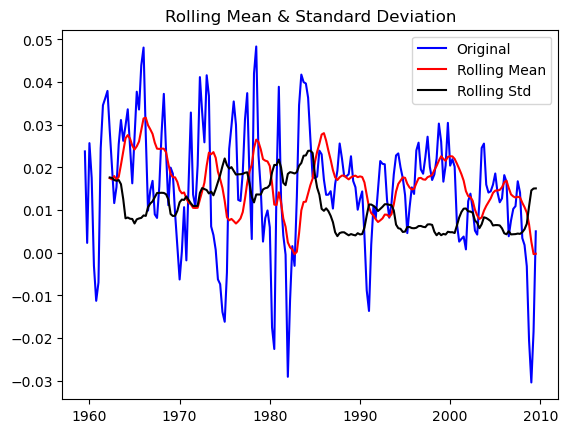

Results of Dickey-Fuller Test: p-value 0.01568544719092446





In [2]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    # determine rolling statistics
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()

    # plot rolling statistics
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    # perform Dickey-Fuller test:
    dftest = adfuller(timeseries)
    print('Results of Dickey-Fuller Test: p-value', dftest[1])
    print("\n\n")

test_stationarity(ts)
test_stationarity(np.log(ts))
test_stationarity(np.log(ts).diff(periods=1).dropna())
test_stationarity(np.log(ts).diff(periods=2).dropna())

Optimal d = 1

In [3]:
ts_log = np.log(ts)
ts_log_diff = (ts_log - ts_log.shift(periods=1)).dropna()

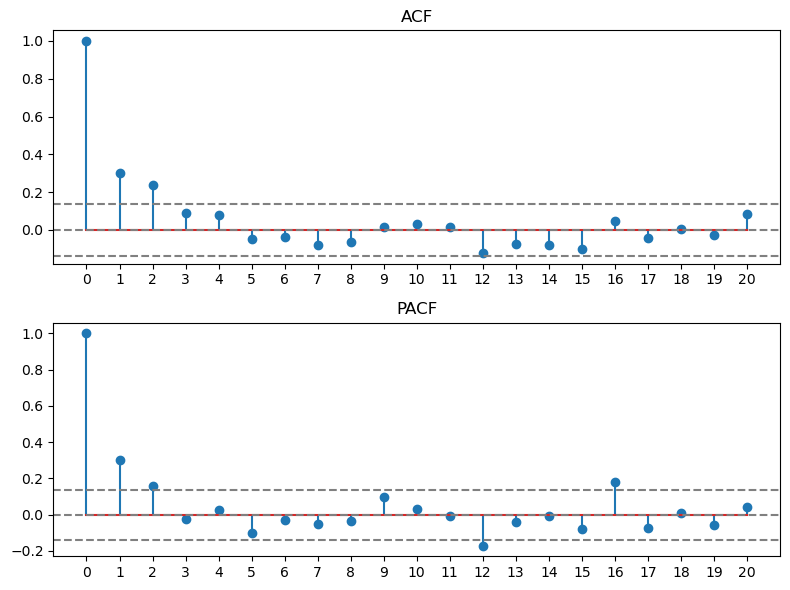

In [4]:
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt

def plot_acf_pacf(ts_diff):
    lag_acf = acf(ts_diff, nlags=20)
    lag_pacf = pacf(ts_diff, nlags=20, method='ols')

    plt.figure(figsize=(8,6))
    plt.subplot(211)
    plt.stem(lag_acf)
    plt.axhline(y=0, linestyle='--', color='gray')
    plt.axhline(y=-1.96/np.sqrt(len(ts_diff)), linestyle='--', color='gray')
    plt.axhline(y=1.96/np.sqrt(len(ts_diff)), linestyle='--', color='gray')
    plt.xticks(range(21))
    plt.title('ACF')

    plt.subplot(212)
    plt.stem(lag_pacf)
    plt.axhline(y=0, linestyle='--', color='gray')
    plt.axhline(y=-1.96/np.sqrt(len(ts_diff)), linestyle='--', color='gray')
    plt.axhline(y=1.96/np.sqrt(len(ts_diff)), linestyle='--', color='gray')
    plt.xticks(range(21))
    plt.title('PACF')
    plt.tight_layout()
    plt.show()


plot_acf_pacf(ts_log_diff)


In [11]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def train_and_plot(ts, p, d, q):
    tscv = TimeSeriesSplit(n_splits=3)

    train_idx, test_idx = list(tscv.split(ts))[-1]
    ts_train, ts_test = ts.iloc[train_idx], ts.iloc[test_idx]
    model = ARIMA(ts_train, order=(p, d, q))
    results_AR = model.fit()
    predictions = results_AR.forecast(steps=len(ts_test))
    plt.figure(figsize=(12, 6))
    plt.plot(ts[1:], label="Full Data", color="lightgray")
    plt.plot(ts_train[1:], label="Train Data", color="blue")
    plt.plot(ts_test, label="Test Data", color="green")
    plt.plot(results_AR.fittedvalues[1:], color='red', label="Fitted Values (Train)")
    plt.plot(ts_test.index, predictions, color='orange', label="Predicted Values (Test)")
    plt.axvline(ts.index[train_idx[-1]], color='black', linestyle='--', label="Train/Test Split")
    plt.title('Train/Test Split with Fitted and Predicted Values')
    plt.legend()
    plt.show()


def train_and_evaluate(ts, p, d, q):
    tscv = TimeSeriesSplit(n_splits=3)

    train_idx, test_idx = list(tscv.split(ts))[-1]
    ts_train, ts_test = ts.iloc[train_idx], ts.iloc[test_idx]
    # train model
    model = ARIMA(ts_train, order=(p, d, q))
    fitted_model = model.fit()
    
    # predict
    forecast = fitted_model.forecast(steps=len(ts_test))
    
    # calculate MSE
    mse = mean_squared_error(ts_test, forecast)
    
    
    print(f"ARIMA{(p, d, q)} MSE: {mse:.2f}")

candidate_models = [
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1),
    (3, 1, 1)
]
for order in candidate_models:
    train_and_evaluate(ts, *order)

ARIMA(1, 1, 0) MSE: 5532344.83
ARIMA(1, 1, 1) MSE: 2500805.58
ARIMA(2, 1, 0) MSE: 4669761.10
ARIMA(2, 1, 1) MSE: 750710.74
ARIMA(3, 1, 1) MSE: 864559.36


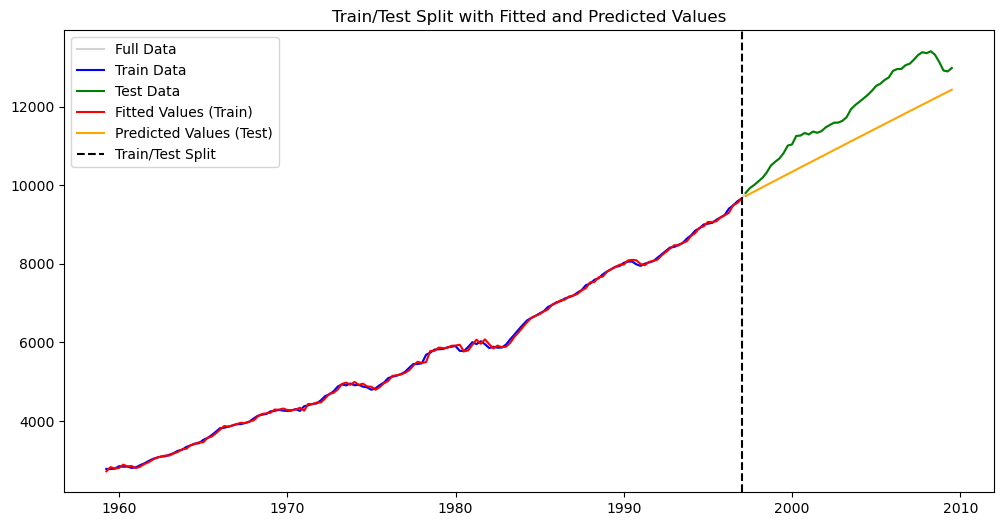

In [10]:
train_and_plot(ts, p=2, d=1, q=1)

-----------------------